# Практическая работа - Теория вероятностей и статистический вывод

---

## Введение

Эта практическая работа предназначена для закрепления теоретических знаний, полученных на лекции по теории вероятностей и статистическому выводу. Ноутбук разбит на секции, соответствующие темам лекции.

### Цели работы:

- Научиться применять теоретические концепции на практике
- Освоить основные инструменты для статистического анализа в Python
- Развить интуитивное понимание ключевых теорем и методов
- Научиться корректно интерпретировать полученные результаты

### Инструкции:

1. Внимательно читайте условия задач — в них содержатся все необходимые данные
2. Для теоретических задач пишите ответы в ячейках Markdown
3. Для практических задач пишите код в ячейках Code
4. Не забывайте комментировать свой код
5. После получения численных результатов делайте выводы

**Начните с выполнения следующей ячейки для импорта библиотек:**

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

# Для воспроизводимости результатов
np.random.seed(42)

print("Библиотеки успешно загружены!")

Библиотеки успешно загружены!


---

## Секция 1: Вероятностное пространство и условная вероятность

В этой секции вы будете работать с основными понятиями теории вероятностей: вероятностным пространством, условной вероятностью и теоремой Байеса.

### Задание 1.1: Описание вероятностного пространства (Теория)

**Условие:**

Рассмотрим эксперимент, в котором одновременно подбрасываются две честные шестигранные игральные кости (на каждой грани числа от 1 до 6). Результат эксперимента — упорядоченная пара чисел (результат первой кости, результат второй кости).

**Задание:**

Опишите вероятностное пространство для этого эксперимента, ответив на следующие вопросы:

1. Что является **элементарным исходом** в этом эксперименте? Приведите 3 примера элементарных исходов.

2. Что является **пространством элементарных исходов** $\Omega$? Опишите его словами и приведите математическую запись.

3. Какова **мощность** (количество элементов) пространства $\Omega$? Обоснуйте свой ответ.

4. Рассмотрим событие $A$ = "сумма очков на двух костях равна 7". Перечислите все элементарные исходы, входящие в это событие.

5. Вычислите вероятность события $A$: $\mathbb{P}(A) = ?$

6. Рассмотрим событие $B$ = "на первой кости выпало 3". Вычислите условную вероятность $\mathbb{P}(A|B)$ — вероятность того, что сумма равна 7, при условии что на первой кости выпало 3.

**Напишите ваши ответы в ячейке ниже:**

1. Элементарный исход: Упорядоченная пара чисел $(i, j)$, где $i$ — результат первой кости, $j$ — результат второй. Примеры: $(1, 1)$, $(3, 5)$, $(6, 2)$.
2. Пространство $\Omega$: Множество всех возможных упорядоченных пар $(i, j)$, где $i, j \in \{1, 2, 3, 4, 5, 6\}$.
3. Мощность $|\Omega|$: $6 \times 6 = 36$, так как для каждого из 6 исходов первой кости есть 6 исходов второй.
4. Событие $A$ (сумма равна 7): $\{(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)\}$.
5. Вероятность $\mathbb{P}(A)$: $6 / 36 = 1/6 \approx 0.167$.
6. Условная вероятность $\mathbb{P}(A|B)$: Если на первой кости выпало 3 (событие $B$), то для суммы 7 на второй обязательно должно выпасть 4. Это ровно 1 исход из 6 возможных для второй кости. $\mathbb{P}(A|B) = 1/6 \approx 0.167$.

### Задание 1.2: Симуляция подбрасываний монеты (Практика)

**Условие:**

Честная монета имеет две стороны: решка (обозначим 0) и орёл (обозначим 1). Теоретическая вероятность выпадения орла равна $p = 0.5$.

**Задание:**

1. С помощью функции `np.random.randint(0, 2, size=n)` сгенерируйте выборку из **100 000** подбрасываний честной монеты.

2. Вычислите **эмпирическую вероятность** выпадения орла (среднее значение выборки).

3. Сравните эмпирическую вероятность с теоретической (0.5) и выведите разницу.

4. **Бонус:** Постройте график, показывающий, как накопленное среднее (cumulative mean) сходится к теоретической вероятности по мере увеличения числа подбрасываний. Это иллюстрация **Закона больших чисел**.

**Подсказки:**
- Для вычисления среднего используйте `np.mean()`
- Для накопленного среднего: `np.cumsum(data) / np.arange(1, len(data) + 1)`
- Для построения графика используйте `plt.plot()` и `plt.axhline()`

Эмпирическая вероятность: 0.50063
Теоретическая вероятность: 0.5
Разница: 0.00063


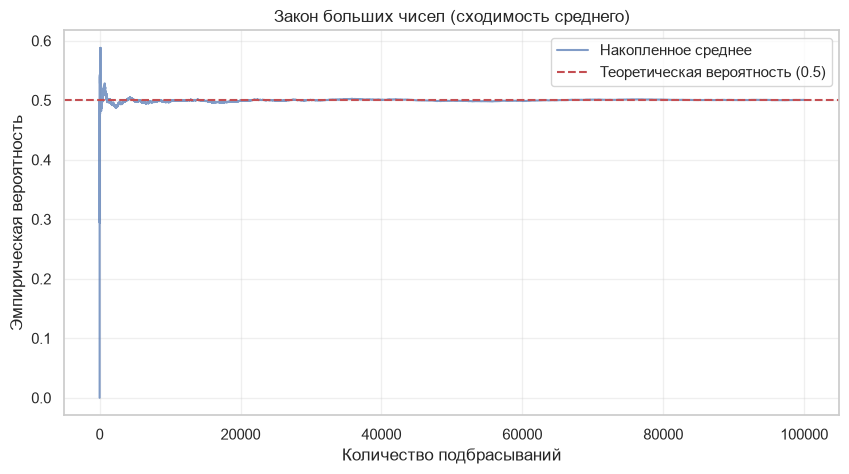

In [2]:
n = 100000
data = np.random.randint(0, 2, size=n)

empirical_prob = np.mean(data)
theoretical_prob = 0.5
diff = abs(empirical_prob - theoretical_prob)

print(f"Эмпирическая вероятность: {empirical_prob:.5f}")
print(f"Теоретическая вероятность: {theoretical_prob}")
print(f"Разница: {diff:.5f}")

cumulative_mean = np.cumsum(data) / np.arange(1, n + 1)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_mean, label='Накопленное среднее', alpha=0.7)
plt.axhline(y=0.5, color='r', linestyle='--', label='Теоретическая вероятность (0.5)')
plt.title('Закон больших чисел (сходимость среднего)')
plt.xlabel('Количество подбрасываний')
plt.ylabel('Эмпирическая вероятность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Задание 1.3: Теорема Байеса в медицинской диагностике (Теория + Практика)

**Условие:**

Редкое заболевание встречается у **0.5%** населения (т.е. вероятность того, что случайный человек болен, равна 0.005).

Для диагностики этого заболевания разработан тест со следующими характеристиками:
- **Чувствительность** (sensitivity): 99% — вероятность положительного результата теста у больного человека: $\mathbb{P}(T^+|D) = 0.99$
- **Специфичность** (specificity): 98% — вероятность отрицательного результата теста у здорового человека: $\mathbb{P}(T^-|D^c) = 0.98$

Пациент прошёл тест и получил **положительный результат**.

**Вопрос:** Какова вероятность того, что пациент действительно болен?

**Задание:**

**Часть А (Теория):** Решите задачу аналитически, используя теорему Байеса.

1. Обозначьте события:
   - $D$ — человек болен
   - $T^+$ — тест положительный

2. Выпишите все известные вероятности:
   - $\mathbb{P}(D) = ?$
   - $\mathbb{P}(T^+|D) = ?$
   - $\mathbb{P}(T^+|D^c) = ?$ (выразите через специфичность)

3. Запишите формулу Байеса для $\mathbb{P}(D|T^+)$

4. Вычислите $\mathbb{P}(T^+)$ по формуле полной вероятности

5. Вычислите итоговый ответ: $\mathbb{P}(D|T^+) = ?$

**Часть Б (Практика):** Напишите код на Python для проверки ваших вычислений.

**Часть В (Интерпретация):** Объясните полученный результат. Почему вероятность болезни при положительном тесте может быть неожиданно низкой?

**Часть А: Аналитическое решение**

*(Напишите ваше решение здесь с формулами)*

1. Известные вероятности:
   - $\mathbb{P}(D) = 0.005$
   - $\mathbb{P}(T^+|D) = 0.99$
   - $\mathbb{P}(T^+|D^c) = 1 - \mathbb{P}(T^-|D^c) = 1 - 0.98 = 0.02$

2. Формула полной вероятности для $\mathbb{P}(T^+)$:
   $\mathbb{P}(T^+) = \mathbb{P}(T^+|D)\mathbb{P}(D) + \mathbb{P}(T^+|D^c)\mathbb{P}(D^c)$
   $\mathbb{P}(T^+) = 0.99 \times 0.005 + 0.02 \times (1 - 0.005) = 0.00495 + 0.0199 = 0.02485$

3. Формула Байеса:
   $\mathbb{P}(D|T^+) = \frac{\mathbb{P}(T^+|D)\mathbb{P}(D)}{\mathbb{P}(T^+)} = \frac{0.00495}{0.02485} \approx 0.1992$

4. Ответ: $\mathbb{P}(D|T^+) \approx 19.92\%$

In [3]:
p_D = 0.005
p_T_pos_given_D = 0.99
p_T_pos_given_not_D = 1 - 0.98

p_T_pos = p_T_pos_given_D * p_D + p_T_pos_given_not_D * (1 - p_D)
p_D_given_T_pos = (p_T_pos_given_D * p_D) / p_T_pos

print(f"Полная вероятность положительного теста P(T+): {p_T_pos:.5f}")
print(f"Вероятность болезни при положительном тесте P(D|T+): {p_D_given_T_pos:.4f} ({p_D_given_T_pos*100:.2f}%)")

Полная вероятность положительного теста P(T+): 0.02485
Вероятность болезни при положительном тесте P(D|T+): 0.1992 (19.92%)


**Часть В: Интерпретация**

Вероятность того, что пациент действительно болен, составляет всего около 19.9%, несмотря на высокую точность теста. Это происходит из-за того, что заболевание редкое (0.5%). 
В абсолютных числах: на 100 000 человек будет 500 больных. Тест правильно найдет 495 из них (99%). Но среди 99 500 здоровых людей тест ошибочно выдаст 2% ложноположительных результатов - это 1990 человек. 
В итоге мы получим 495 истинно больных и 1990 ложноположительных. Доля реальных больных среди всех получивших положительный тест составит 495 / (495 + 1990) примерно 19.9%. Это парадокс базового процента.

---

## Секция 2: Случайные величины и распределения

В этой секции вы будете работать с дискретными и непрерывными случайными величинами, вычислять их характеристики и работать с распределениями.

### Задание 2.1: Лотерея — расчёт математического ожидания и дисперсии (Теория)

**Условие:**

В лотерее продаётся **100 билетов** по цене **100 рублей** каждый. Призовой фонд распределён следующим образом:
- **1 билет** выигрывает главный приз: **5000 рублей**
- **5 билетов** выигрывают по **1000 рублей**
- **10 билетов** выигрывают по **100 рублей**
- Остальные **84 билета** — невыигрышные (выигрыш 0 рублей)

Пусть случайная величина $X$ — это сумма выигрыша для одного купленного билета (без вычета стоимости билета).

**Задание:**

1. Составьте **закон распределения** для случайной величины $X$ в виде таблицы:

| Значение $x_i$ | 0 | 100 | 1000 | 5000 |
|---|---|---|---|---|
| Вероятность $p_i$ | ? | ? | ? | ? |

2. Вычислите **математическое ожидание** выигрыша: $\mathbb{E}[X] = \sum x_i \cdot p_i$

3. Определите, является ли лотерея **справедливой** для игрока. Лотерея считается справедливой, если математическое ожидание выигрыша равно цене билета (100 рублей). Если $\mathbb{E}[X] > 100$, лотерея выгодна игроку; если $\mathbb{E}[X] < 100$, выгодна организатору.

4. Вычислите **дисперсию** выигрыша: $\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$
   - Сначала найдите $\mathbb{E}[X^2] = \sum x_i^2 \cdot p_i$
   - Затем вычислите дисперсию

5. Найдите **стандартное отклонение**: $\sigma = \sqrt{\text{Var}(X)}$

6. Интерпретируйте результаты: что означают полученные значения математического ожидания и дисперсии для игрока?

**Ваше решение:**

1. Закон распределения:
| Значение $x_i$ | 0 | 100 | 1000 | 5000 |
|---|---|---|---|---|
| Вероятность $p_i$ | 0.84 | 0.10 | 0.05 | 0.01 |

2. Математическое ожидание:
$\mathbb{E}[X] = 0 \times 0.84 + 100 \times 0.10 + 1000 \times 0.05 + 5000 \times 0.01 = 0 + 10 + 50 + 50 = 110$ руб.

3. Справедливость лотереи:
Так как $\mathbb{E}[X] = 110$ руб., а билет стоит 100 руб., то $\mathbb{E}[X] > 100$. Лотерея **выгодна игроку** (справедлива с перевесом в пользу игрока).

4. Дисперсия:
$\mathbb{E}[X^2] = 0^2 \times 0.84 + 100^2 \times 0.10 + 1000^2 \times 0.05 + 5000^2 \times 0.01 = 0 + 1000 + 50000 + 250000 = 301000$
$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = 301000 - 110^2 = 301000 - 12100 = 288900$

5. Стандартное отклонение:
$\sigma = \sqrt{288900} \approx 537.49$

6. Интерпретация:
В среднем игрок выигрывает 110 рублей (чистая прибыль 10 рублей с билета). Однако огромное стандартное отклонение (537 руб.) говорит о колоссальном разбросе: игрок либо потеряет 100 рублей (с вероятностью 84%), либо сорвет куш, многократно превышающий затраты.

### Задание 2.2: Работа с нормальным распределением (Практика)

**Условие:**

Рост взрослых мужчин в некоторой стране распределён нормально со средним значением **μ = 175 см** и стандартным отклонением **σ = 8 см**.

**Задание:**

1. С помощью `scipy.stats.norm.rvs()` сгенерируйте выборку из **1000 наблюдений** из нормального распределения $\mathcal{N}(175, 8^2)$.
   - Параметры: `loc=175` (среднее), `scale=8` (стандартное отклонение), `size=1000`

2. Постройте **гистограмму** распределения роста с параметром `density=True` (нормированная гистограмма).

3. На том же графике постройте **теоретическую кривую плотности** нормального распределения $\mathcal{N}(175, 8^2)$ с помощью `stats.norm.pdf()`.

4. Вычислите **выборочное среднее** и **выборочное стандартное отклонение** (используйте `ddof=1` для несмещённой оценки).

5. Сравните выборочные характеристики с теоретическими:
   - Теоретическое среднее: 175 см
   - Теоретическое СКО: 8 см

6. **Бонус:** Вычислите, какой процент мужчин имеет рост от 167 см до 183 см (это интервал μ ± σ). Сравните с теоретическим значением ~68% (правило "трёх сигм").

**Подсказки:**
- `np.mean()` и `np.std(ddof=1)` для выборочных характеристик
- `np.sum((data >= 167) & (data <= 183)) / len(data)` для подсчёта процента

Выборочное среднее: 175.15 см
Выборочное СКО: 7.83 см


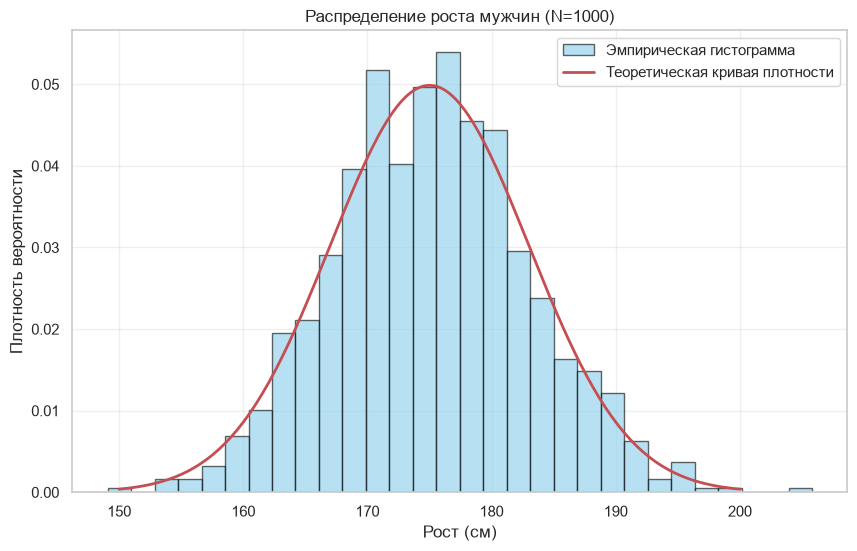


Процент мужчин с ростом от 167 до 183 см: 69.80%
(Теоретическое значение по правилу 68-95-99.5: ~68.27%)


In [4]:
data = stats.norm.rvs(loc=175, scale=8, size=1000, random_state=42)

sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)

print(f"Выборочное среднее: {sample_mean:.2f} см")
print(f"Выборочное СКО: {sample_std:.2f} см")

x_range = np.linspace(150, 200, 200)
pdf = stats.norm.pdf(x_range, loc=175, scale=8)

plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Эмпирическая гистограмма')
plt.plot(x_range, pdf, 'r-', lw=2, label='Теоретическая кривая плотности')
plt.title('Распределение роста мужчин (N=1000)')
plt.xlabel('Рост (см)')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pct_in_interval = np.sum((data >= 167) & (data <= 183)) / len(data) * 100
print(f"\nПроцент мужчин с ростом от 167 до 183 см: {pct_in_interval:.2f}%")
print("(Теоретическое значение по правилу 68-95-99.5: ~68.27%)")

---

## Секция 3: Совместные, маргинальные и условные распределения

В этой секции вы будете работать с несколькими случайными величинами одновременно и изучать их взаимосвязь.

### Задание 3.1: Ковариация и корреляция (Практика)

**Условие:**

Рассмотрим две случайные величины:
- $X \sim \mathcal{N}(0, 1)$ — стандартное нормальное распределение
- $Y = 2X + \epsilon$, где $\epsilon \sim \mathcal{N}(0, 1)$ — независимый шум

Таким образом, $Y$ линейно зависит от $X$ с добавлением случайного шума.

**Задание:**

1. Сгенерируйте выборку из **1000 наблюдений**:
   - $X$: используйте `np.random.normal(0, 1, 1000)`
   - $\epsilon$: используйте `np.random.normal(0, 1, 1000)`
   - $Y$: вычислите как `Y = 2 * X + epsilon`

2. Постройте **диаграмму рассеяния** (scatter plot) для пар $(X, Y)$.
   - Используйте `plt.scatter(X, Y, alpha=0.5)`

3. Вычислите **выборочную ковариацию** между $X$ и $Y$:
   - Используйте `np.cov(X, Y)[0, 1]` (внедиагональный элемент ковариационной матрицы)

4. Вычислите **выборочную корреляцию** между $X$ и $Y$:
   - Используйте `np.corrcoef(X, Y)[0, 1]`

5. Интерпретируйте результаты:
   - Является ли корреляция положительной или отрицательной?
   - Почему корреляция не равна 1, хотя $Y$ зависит от $X$?
   - Что означает значение корреляции (например, 0.9)?

6. **Бонус:** Добавьте на диаграмму рассеяния линию линейной регрессии с помощью `np.polyfit()` и `np.poly1d()`.

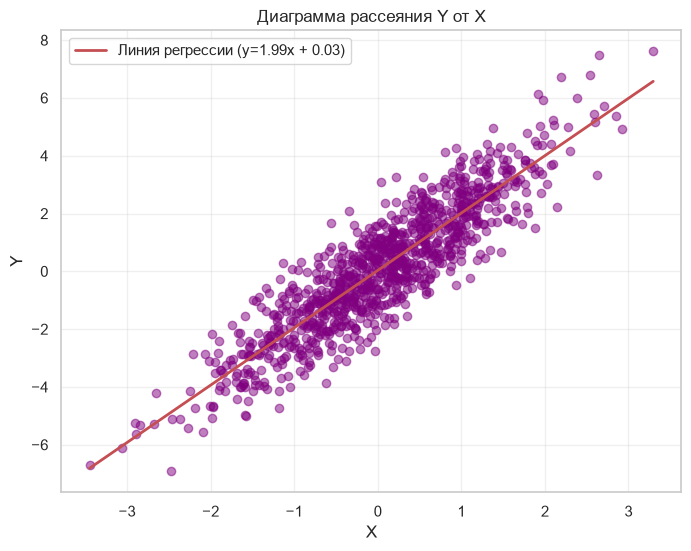

Выборочная ковариация: 1.9791
Выборочная корреляция: 0.8972


In [5]:
n = 1000
X = np.random.normal(0, 1, n)
epsilon = np.random.normal(0, 1, n)
Y = 2 * X + epsilon

plt.figure(figsize=(8, 6))
plt.scatter(X, Y, alpha=0.5, color='purple')

coeffs = np.polyfit(X, Y, 1)
poly_func = np.poly1d(coeffs)
x_line = np.linspace(X.min(), X.max(), 100)
plt.plot(x_line, poly_func(x_line), 'r-', lw=2, label=f'Линия регрессии (y={coeffs[0]:.2f}x + {coeffs[1]:.2f})')

plt.title('Диаграмма рассеяния Y от X')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

cov_xy = np.cov(X, Y)[0, 1]
corr_xy = np.corrcoef(X, Y)[0, 1]

print(f"Выборочная ковариация: {cov_xy:.4f}")
print(f"Выборочная корреляция: {corr_xy:.4f}")

**Интерпретация результатов:**

* Корреляция положительная и сильная, так как коэффициент при X в формуле положительный.
* Корреляция не равна 1, потому что в модели присутствует случайный шум $\epsilon$. Переменная Y зависит от X не детерминировано, а стохастически.
* Значение корреляции означает, что между X и Y существует сильная линейная связь, но около 19% дисперсии Y объясняется не переменной X, а случайным шумом.

---

## Секция 4: Предельные теоремы

В этой секции вы будете экспериментально проверять два фундаментальных результата теории вероятностей: Закон больших чисел и Центральную предельную теорему.

### Задание 4.1: Закон больших чисел (Практика)

**Условие:**

Рассмотрим эксперимент с подбрасыванием честной шестигранной кости. Теоретическое математическое ожидание выпавшего числа равно:
$$\mathbb{E}[X] = \frac{1 + 2 + 3 + 4 + 5 + 6}{6} = 3.5$$

Закон больших чисел утверждает, что при увеличении числа подбрасываний выборочное среднее будет сходиться к теоретическому математическому ожиданию.

**Задание:**

1. Сгенерируйте выборку из **10 000 подбрасываний** кости:
   - Используйте `np.random.randint(1, 7, size=10000)`

2. Вычислите **накопленное среднее** (cumulative mean) для каждого момента времени от 1 до 10000:
   - `cumulative_mean = np.cumsum(rolls) / np.arange(1, 10001)`

3. Постройте график зависимости накопленного среднего от числа подбрасываний:
   - По оси X: число подбрасываний (от 1 до 10000)
   - По оси Y: накопленное среднее
   - Добавьте горизонтальную линию на уровне 3.5 (теоретическое среднее)

4. Выведите итоговое среднее после 10000 подбрасываний и его отклонение от 3.5.

5. Сделайте вывод: подтверждается ли Закон больших чисел вашим экспериментом?

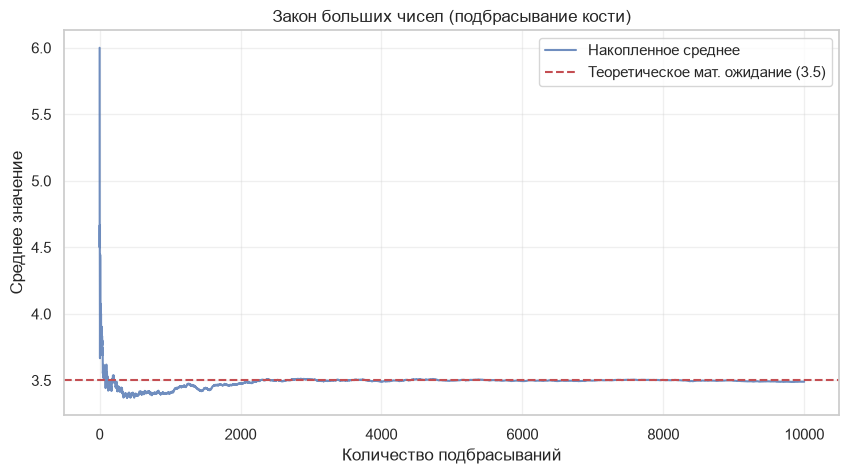

Итоговое среднее после 10000 бросков: 3.4893
Отклонение от 3.5: 0.0107


In [6]:
rolls = np.random.randint(1, 7, size=10000)
cumulative_mean = np.cumsum(rolls) / np.arange(1, 10001)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_mean, label='Накопленное среднее', alpha=0.8)
plt.axhline(y=3.5, color='r', linestyle='--', label='Теоретическое мат. ожидание (3.5)')
plt.title('Закон больших чисел (подбрасывание кости)')
plt.xlabel('Количество подбрасываний')
plt.ylabel('Среднее значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_mean = cumulative_mean[-1]
print(f"Итоговое среднее после 10000 бросков: {final_mean:.4f}")
print(f"Отклонение от 3.5: {abs(final_mean - 3.5):.4f}")

**Вывод:**

Закон больших чисел полностью подтверждается. На начальном этапе среднее значение варьируется. Однако по мере увеличения количества испытаний график стабилизируется и приближается к теоретическому математическому ожиданию.

### Задание 4.2: Центральная предельная теорема (Практика)

**Условие:**

Центральная предельная теорема (ЦПТ) утверждает, что распределение выборочных средних приближается к нормальному распределению при увеличении размера выборки, **независимо от исходного распределения**.

Мы будем использовать равномерное распределение на отрезке [0, 1], которое имеет:
- Среднее: $\mu = 0.5$
- Дисперсию: $\sigma^2 = \frac{1}{12} \approx 0.0833$

Согласно ЦПТ, выборочное среднее $\bar{X}_n$ из $n$ наблюдений имеет приближённое распределение:
$$\bar{X}_n \sim \mathcal{N}\left(0.5, \frac{1}{12n}\right)$$

**Задание:**

1. Для каждого из трёх размеров выборки ($n = 5$, $n = 30$, $n = 100$):
   - Сгенерируйте **1000 выборок** размера $n$ из равномерного распределения `np.random.uniform(0, 1, n)`
   - Для каждой выборки вычислите среднее
   - Сохраните все 1000 средних в массив

2. Постройте **три гистограммы** (можно использовать `plt.subplots(1, 3)`) для распределения средних при $n = 5$, $n = 30$ и $n = 100$.

3. На каждой гистограмме постройте теоретическую кривую нормального распределения:
   - Среднее: 0.5
   - СКО: $\sqrt{\frac{1}{12n}}$

4. Для каждого случая выведите:
   - Выборочное среднее средних (должно быть близко к 0.5)
   - Выборочное СКО средних (должно быть близко к $\sqrt{\frac{1}{12n}}$)

5. Сделайте вывод: как меняется распределение выборочных средних при увеличении $n$? Подтверждается ли ЦПТ?

n=5: Выборочное среднее средних = 0.4971, Теор. СКО = 0.1291, Эмп. СКО = 0.1239
n=30: Выборочное среднее средних = 0.5002, Теор. СКО = 0.0527, Эмп. СКО = 0.0516
n=100: Выборочное среднее средних = 0.5011, Теор. СКО = 0.0289, Эмп. СКО = 0.0290


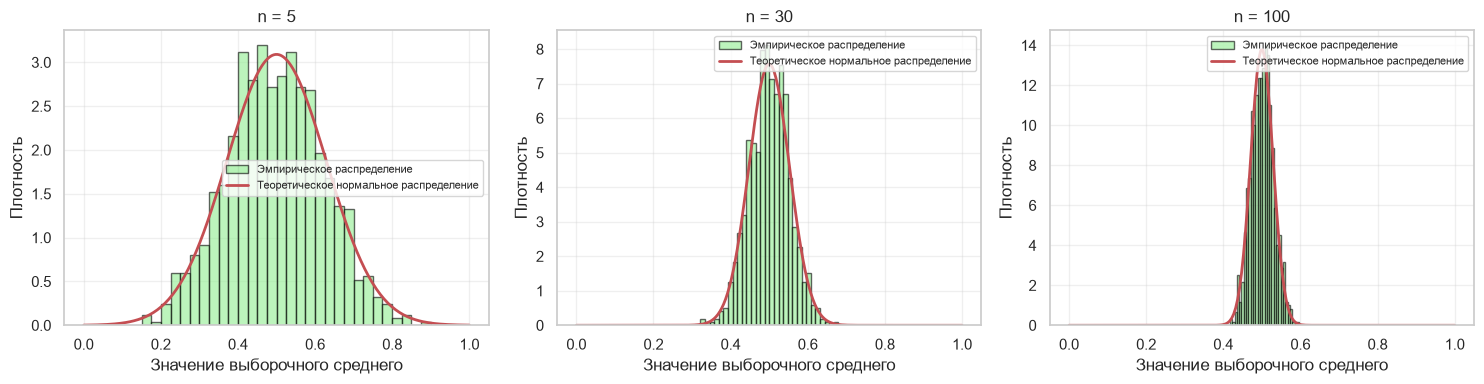

In [7]:
n_samples = 1000
sample_sizes = [5, 30, 100]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n in zip(axes, sample_sizes):
    sample_means = np.array([np.mean(np.random.uniform(0, 1, n)) for _ in range(n_samples)])
    
    ax.hist(sample_means, bins=30, density=True, alpha=0.6, color='lightgreen', edgecolor='black', label='Эмпирическое распределение')
    
    theoretical_std = np.sqrt(1 / (12 * n))
    x_range = np.linspace(0, 1, 200)
    pdf = stats.norm.pdf(x_range, loc=0.5, scale=theoretical_std)
    ax.plot(x_range, pdf, 'r-', lw=2, label='Теоретическое нормальное распределение')
    
    ax.set_title(f'n = {n}')
    ax.set_xlabel('Значение выборочного среднего')
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    print(f"n={n}: Выборочное среднее средних = {np.mean(sample_means):.4f}, Теор. СКО = {theoretical_std:.4f}, Эмп. СКО = {np.std(sample_means, ddof=1):.4f}")

plt.tight_layout()
plt.show()

**Вывод:**
Центральная предельная теорема подтверждается. 
1. При малом $n=5$ гистограмма средних лишь отдаленно напоминает нормальное распределение.
2. При увеличении $n$ до 30 и 100 эмпирическое распределение выборочных средних становится колоколообразной кривой.
3. Математическое ожидание выборочных средних всегда остается равным 0.5, а стандартное отклонение уменьшается пропорционально $1/\sqrt{n}$, что совпадает с теоретическими значениями.

---

## Секция 5: Статистическое оценивание

В этой секции вы будете оценивать параметры распределений по выборкам и строить доверительные интервалы.

### Задание 5.1: Метод максимального правдоподобия (Практика)

**Условие:**

Монета подбрасывается $n = 100$ раз. Истинная вероятность выпадения орла равна $p = 0.3$ (но мы делаем вид, что не знаем этого и хотим оценить $p$ по данным).

Для распределения Бернулли логарифмическая функция правдоподобия имеет вид:
$$\ell(p) = k \ln(p) + (n - k) \ln(1 - p)$$
где $k$ — число успехов (орлов) в выборке.

Оценка максимального правдоподобия для $p$ равна $\hat{p}_{\text{MLE}} = \frac{k}{n}$ (выборочная доля успехов).

**Задание:**

1. Сгенерируйте выборку из 100 подбрасываний монеты с $p = 0.3$:
   - Используйте `np.random.binomial(1, 0.3, 100)`

2. Посчитайте число успехов $k$ в выборке: `k = np.sum(data)`

3. Вычислите оценку МП: $\hat{p}_{\text{MLE}} = k / 100$

4. Постройте график логарифмической функции правдоподобия $\ell(p)$ для значений $p$ от 0.01 до 0.99:
   - Создайте массив `p_values = np.linspace(0.01, 0.99, 100)`
   - Для каждого $p$ вычислите $\ell(p) = k \cdot \ln(p) + (n - k) \cdot \ln(1 - p)$
   - Постройте график `plt.plot(p_values, log_likelihoods)`

5. На графике отметьте вертикальными линиями:
   - Оценку МП $\hat{p}_{\text{MLE}}$ (красная линия)
   - Истинное значение $p = 0.3$ (зелёная линия)

6. Убедитесь, что максимум функции правдоподобия достигается в точке $\hat{p}_{\text{MLE}}$.

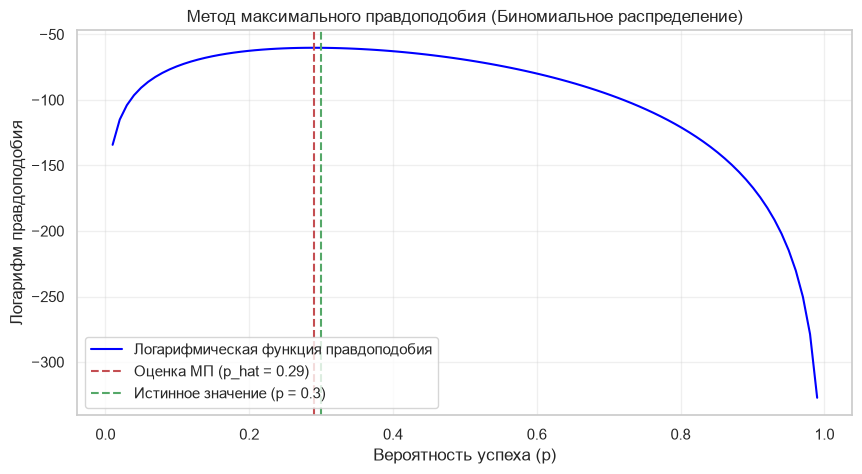

Число успехов (k): 29
Оценка МП (p_hat): 0.29


In [8]:
n = 100
p_true = 0.3
data = np.random.binomial(1, p_true, n)

k = np.sum(data)
p_mle = k / n

p_values = np.linspace(0.01, 0.99, 100)
log_likelihoods = k * np.log(p_values) + (n - k) * np.log(1 - p_values)

plt.figure(figsize=(10, 5))
plt.plot(p_values, log_likelihoods, label='Логарифмическая функция правдоподобия', color='blue')
plt.axvline(x=p_mle, color='r', linestyle='--', label=f'Оценка МП (p_hat = {p_mle:.2f})')
plt.axvline(x=p_true, color='g', linestyle='--', label=f'Истинное значение (p = {p_true})')
plt.title('Метод максимального правдоподобия (Биномиальное распределение)')
plt.xlabel('Вероятность успеха (p)')
plt.ylabel('Логарифм правдоподобия')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Число успехов (k): {k}")
print(f"Оценка МП (p_hat): {p_mle}")

### Задание 5.2: Доверительный интервал для среднего (Практика)

**Условие:**

Исследователь измерил время реакции (в секундах) у 25 испытуемых и получил следующие данные:

```
[0.42, 0.38, 0.41, 0.43, 0.39, 0.40, 0.45, 0.40, 0.42, 0.37,
 0.39, 0.46, 0.38, 0.42, 0.41, 0.40, 0.40, 0.43, 0.39, 0.41,
 0.40, 0.38, 0.44, 0.42, 0.39]
```

Предполагается, что время реакции распределено нормально. Необходимо построить **95% доверительный интервал** для среднего времени реакции в популяции.

**Формула доверительного интервала:**
$$\left[\bar{x} - t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}, \ \bar{x} + t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}\right]$$

где:
- $\bar{x}$ — выборочное среднее
- $s$ — выборочное стандартное отклонение (с `ddof=1`)
- $n$ — размер выборки
- $t_{\alpha/2, n-1}$ — критическое значение t-распределения с $n-1$ степенями свободы

**Задание:**

1. Загрузите данные в массив NumPy.

2. Вычислите:
   - Размер выборки $n$
   - Выборочное среднее $\bar{x}$
   - Выборочное СКО $s$ (с `ddof=1`)
   - Стандартную ошибку среднего: $SE = s / \sqrt{n}$

3. Найдите критическое значение t-распределения для уровня доверия 95%:
   - Используйте `stats.t.ppf(0.975, df=n-1)` (0.975 = 1 - 0.05/2)

4. Вычислите границы доверительного интервала:
   - Нижняя граница: $\bar{x} - t \cdot SE$
   - Верхняя граница: $\bar{x} + t \cdot SE$

5. Выведите результаты и интерпретируйте: что означает этот доверительный интервал?

In [9]:
data = np.array([0.42, 0.38, 0.41, 0.43, 0.39, 0.40, 0.45, 0.40, 0.42, 0.37,
                 0.39, 0.46, 0.38, 0.42, 0.41, 0.40, 0.40, 0.43, 0.39, 0.41,
                 0.40, 0.38, 0.44, 0.42, 0.39])

n = len(data)
x_bar = np.mean(data)
s = np.std(data, ddof=1)
se = s / np.sqrt(n)

t_crit = stats.t.ppf(0.975, df=n-1)

ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se

print(f"Размер выборки (n): {n}")
print(f"Выборочное среднее: {x_bar:.4f}")
print(f"Выборочное СКО (s): {s:.4f}")
print(f"Стандартная ошибка (SE): {se:.4f}")
print(f"Критическое значение t-критерия: {t_crit:.4f}")
print(f"95% Доверительный интервал: [{ci_lower:.4f}, {ci_upper:.4f}]")

Размер выборки (n): 25
Выборочное среднее: 0.4076
Выборочное СКО (s): 0.0228
Стандартная ошибка (SE): 0.0046
Критическое значение t-критерия: 2.0639
95% Доверительный интервал: [0.3982, 0.4170]


**Интерпретация:**
Среднее время реакции всей популяции людей находится в пределах 0.3982, 0.4170 секунд. Это не означает, что 95% людей имеют такое время реакции, а означает надежность самой оценки: если бы мы многократно брали новые выборки и строили по ним такие интервалы, в 95% случаев истинное среднее попадало бы внутрь этих границ.

---

## Секция 6: Проверка статистических гипотез

В этой секции вы будете проверять статистические гипотезы с помощью различных тестов.

### Задание 6.1: Одновыборочный t-тест (Практика)

**Условие:**

Производитель утверждает, что среднее время работы батарейки составляет **μ₀ = 50 часов**. Исследователь решил проверить это утверждение и измерил время работы у 20 батареек:

```
[48.2, 51.3, 49.8, 52.1, 47.5, 50.2, 49.1, 51.8, 48.9, 50.5,
 49.3, 52.4, 48.7, 50.9, 49.5, 51.2, 48.4, 50.7, 49.9, 51.0]
```

Необходимо проверить гипотезу о том, что среднее время работы отличается от заявленного.

**Гипотезы:**
- $H_0: \mu = 50$ (нулевая гипотеза: среднее равно 50)
- $H_a: \mu \neq 50$ (альтернативная гипотеза: среднее не равно 50)

**Уровень значимости:** $\alpha = 0.05$

**Задание:**

1. Загрузите данные в массив NumPy.

2. Выполните одновыборочный t-тест с помощью `scipy.stats.ttest_1samp(data, 50)`.
   - Функция вернёт t-статистику и p-value

3. Выведите:
   - Выборочное среднее
   - t-статистику
   - p-value

4. Примите решение:
   - Если $p < \alpha$, отклоняем $H_0$
   - Если $p \geq \alpha$, не отклоняем $H_0$

5. Сформулируйте вывод в контексте задачи: есть ли статистически значимые доказательства того, что среднее время работы батареек отличается от 50 часов?

In [10]:
data = np.array([48.2, 51.3, 49.8, 52.1, 47.5, 50.2, 49.1, 51.8, 48.9, 50.5,
                 49.3, 52.4, 48.7, 50.9, 49.5, 51.2, 48.4, 50.7, 49.9, 51.0])

t_stat, p_value = stats.ttest_1samp(data, 50)
sample_mean = np.mean(data)

print(f"Выборочное среднее: {sample_mean:.4f}")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    decision = "Отклоняем H0"
else:
    decision = "Не отклоняем H0"
print(f"Решение (при alpha={alpha}): {decision}")

Выборочное среднее: 50.0700
t-статистика: 0.2288
p-value: 0.8215
Решение (при alpha=0.05): Не отклоняем H0


**Вывод:**
Так как p-value > 0.05, то нет оснований отклонить нулевую гипотезу. Выборочное среднее статистически незначимо отличается от заявленных 50 часов. Разброс в данных объясняется естественной случайной вариативностью, а не тем, что производитель намеренно завышает характеристики.

---

## Секция 7: Зависимость, условная независимость и причинность

В этой секции вы будете различать корреляцию и причинность.

### Задание 7.1: Корреляция vs. причинность (Теория)

**Задание:**

Приведите **свой собственный пример** из реальной жизни, иллюстрирующий принцип **"корреляция не означает причинно-следственную связь"**.

Ваш пример должен содержать:

1. **Две коррелирующие переменные** $X$ и $Y$ (опишите их)

2. **Наблюдаемую корреляцию** (положительную или отрицательную)

3. **Ошибочный причинный вывод**, который можно было бы сделать

4. **Скрытую (смешивающую) переменную** $Z$, которая является истинной причиной обеих переменных

5. **Правильное объяснение** механизма связи

**Пример структуры ответа:**

- Переменная X: ...
- Переменная Y: ...
- Наблюдение: X и Y положительно коррелируют
- Ошибочный вывод: X вызывает Y (или наоборот)
- Скрытая переменная Z: ...
- Правильное объяснение: Z влияет на X и Y независимо, создавая иллюзию связи между ними

**Требование:** Не используйте классические примеры из учебников (мороженое и утопления, пираты и глобальное потепление и т.д.). Придумайте свой!

**Ваш пример:**
* **Переменная X:** Количество вызовов скорой помощи в районе за день.
* **Переменная Y:** Количество зарегистрированных краж со взломом в том же районе за день.
* **Наблюдение:** X и Y имеют сильную положительную корреляцию (в дни с большим количеством вызовов скорой обычно больше и краж).
* **Ошибочный вывод:** Приезд врачей провоцирует преступников, или наоборот, активность воров приводит к тому, что люди чаще вызывают скорую от стресса.
* **Скрытая переменная Z:** День недели / Погода / Праздник. Например, в теплые летние выходные люди больше гуляют, оставляя окна открытыми (что ведет к кражам), и чаще получают травмы на улице или травятся некачественной едой из забегаловок.
* **Правильное объяснение:** Z (сезонно-погодный фактор) независимо увеличивает как уязвимость жилья для краж, так и количество бытовых травм, создавая ложную иллюзию прямой причинно-следственной связи между скорой и преступностью.

---

## Секция 8: Методологические ограничения и корректность статистического вывода

В этой секции вы будете анализировать типичные ошибки в статистических исследованиях.

### Задание 8.1: Ошибка выжившего (Survivorship Bias) (Теория)

**Задание:**

Прочитайте описание ситуации и ответьте на вопросы.

**Ситуация:**

Бизнес-аналитик хочет понять, какие факторы приводят к успеху стартапов в сфере технологий. Он анализирует данные о 50 успешных компаниях (таких как Google, Apple, Amazon, Facebook и т.д.), которые достигли капитализации более $1 млрд. На основе этого анализа он делает следующие выводы:

- "90% успешных стартапов были основаны людьми моложе 30 лет → молодость основателя — ключ к успеху"
- "80% успешных стартапов агрессивно привлекали венчурные инвестиции на ранних стадиях → нужно как можно быстрее привлекать инвестиции"
- "70% успешных стартапов имели минималистичный дизайн продукта → простота — залог успеха"

**Вопросы:**

1. Какая методологическая ошибка допущена в этом исследовании? Назовите её и объясните суть.

2. Почему выводы аналитика могут быть ошибочными или вводящими в заблуждение?

3. Какие данные **отсутствуют** в анализе, но необходимы для корректных выводов?

4. Приведите гипотетический пример, показывающий, как учёт "невыживших" мог бы изменить выводы (например, про возраст основателей).

5. Как правильно спроектировать исследование, чтобы избежать этой ошибки?

6. Приведите ещё один пример из любой другой области (медицина, образование, спорт и т.д.), где может возникнуть ошибка выжившего.

**Ваши ответы:**

Название и суть ошибки: Ошибка выжившего. Суть заключается в том, что аналитик делает выводы только на основе "выжившей" части данных, полностью игнорируя ту часть, которая "погибла", потому что по ней нет наблюдений.
Почему выводы ошибочны: Аналитик не учитывает, что те же самые черты могли быть в равной степени присущи тысячам стартапов, которые прогорели и исчезли.
Отсутствующие данные: Данные о тысячах неудачных стартапов, их возрасте основателей, дизайнах продуктов и историях привлечения инвестиций.
Гипотетический пример: Если бы аналитик посмотрел на "невыживших", он мог бы обнаружить, что 95% прогоревших стартапов тоже были основаны людьми моложе 30 лет. Это означало бы, что молодость вообще не дает никаких преимуществ, а успех зависит от других факторов.
Правильный дизайн исследования: Необходимо проводить когортное исследование, сравнивая характеристики группы успешных стартапов с контрольной группой неудачных стартапов из той же отрасли и того же временного периода, чтобы выявить факторы, которые статистически значимо *отличают* winners от losers.
Пример из другой области: Авиация во время Второй мировой войны. Военные анализировали самолеты, вернувшиеся с боями, и видели, что фюзеляж весь в пробоинах, а двигатели целы. Они хотели усилить броню фюзеляжа. Но статистик указал на ошибку выжившего - нужно бронировать двигатели. Те самолеты, которым попали в двигатель, просто не вернулись на базу и не попали в выборку для анализа.

---

## Заключение

### Что вы изучили:

- Вероятностное пространство и условную вероятность
- Случайные величины и их распределения
- Совместные распределения, ковариацию и корреляцию
- Предельные теоремы (ЗБЧ и ЦПТ)
- Методы статистического оценивания
- Проверку статистических гипотез
- Различие между корреляцией и причинностью
- Методологические ошибки в статистических исследованиях

Эти знания являются фундаментом для дальнейшего изучения машинного обучения и анализа данных.